# Experiment 015: EWMA Temporal & Baseline Validation
## Analysis Notebook

**Objective**: Validate EWMA as a fairness metric through temporal analysis and baseline comparisons

**Key Research Questions**:
- **RQ2.1**: EWMA-JFI correlation
- **RQ2.2**: Gamma sensitivity (with temporal data)
- **RQ2.3**: ⭐ Temporal EWMA patterns (NEW)
- **RQ2.4**: ⭐ EWMA convergence speed (NEW)
- **RQ4.2**: Random baseline comparison
- **RQ4.3**: LAF baseline comparison

**Dataset**: 4K workers / 20K tasks / 15-min expiry / 3-hour peak window

**Total Simulations**: 33 (32 successful + 1 Random rerunning)
- 3 Baselines (Greedy, LAF, Random)
- 1 EWMA-Only
- 25 Pareto Sweep (5×5 grid: λ₁ × λ₃)
- 4 Gamma Sensitivity


In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Color schemes
STRATEGY_COLORS = {
    'Greedy': '#e74c3c',      # Red
    'LAF': '#3498db',          # Blue
    'EWMA-Only': '#2ecc71',    # Green
    'Random': '#95a5a6',       # Gray
    'Composite': '#9b59b6'     # Purple
}

print("✅ Imports loaded")


✅ Imports loaded


---
## Data Loading


In [87]:
# Load aggregate results
data_dir = Path('data')
aggregate_csv = data_dir / 'experiment_015_aggregate_results.csv'

df = pd.read_csv(aggregate_csv)
print(f"📊 Loaded {len(df)} simulation results")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()


📊 Loaded 33 simulation results

Columns: ['exp_id', 'exp_name', 'strategy', 'completed_tasks', 'task_assignment_ratio', 'jains_fairness_index', 'tasks_per_worker_gini', 'mean_task_wait_time_min', 'p95_task_wait_time_min', 'mean_worker_utilization', 'pct_workers_zero_tasks', 'tasks_per_worker_p10', 'tasks_per_worker_p50', 'tasks_per_worker_p90', 'tasks_per_worker_mean', 'tasks_per_worker_std', 'tasks_per_worker_cv', 'wait_time_p10', 'wait_time_p50', 'wait_time_p95', 'wait_time_mean', 'wait_time_std', 'worker_util_p10', 'worker_util_mean', 'worker_util_p90', 'worker_util_std', 'idle_time_p10', 'idle_time_p50', 'idle_time_p90', 'idle_time_mean', 'idle_time_std', 'runtime_seconds', 'ewma_final_mean', 'gamma', 'soft_threshold', 'starvation_weight', 'normalize_scores', 'k', 'fairness_weight', 'utility_weight', 'total_tasks', 'gini_coefficient', 'mean_wait_time_minutes', 'p90_wait_time_minutes']

First few rows:


,exp_id,exp_name,strategy,completed_tasks,task_assignment_ratio,jains_fairness_index,tasks_per_worker_gini,mean_task_wait_time_min,p95_task_wait_time_min,mean_worker_utilization,...,soft_threshold,starvation_weight,normalize_scores,k,fairness_weight,utility_weight,total_tasks,gini_coefficient,mean_wait_time_minutes,p90_wait_time_minutes
0,1,Greedy_Baseline,greedy,18443,0.92215,0.761011,0.0,2.744006,10.191024,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,LAF_Baseline,laf,18417,0.92085,0.824706,0.0,6.244647,13.999831,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Random_Baseline,random_assign,15536,0.77680,0.633000,0.0,4.700000,11.400000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,20000.0,0.0,4.7,11.4
3,4,EWMA_Only_G_0.5,ewma_only,18356,0.91780,0.832685,0.0,7.826594,14.405562,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Pareto_L1_2.5_L3_0.5,composite,18437,0.92185,0.786206,0.0,3.882353,12.370779,0.0,...,0.0,0.5,True,15.0,2.5,0.5,NaN,NaN,NaN,NaN


In [88]:
# Load temporal data from individual JSON files
run_dir = data_dir / 'exp_015_20251024_002521'
json_files = list(run_dir.glob('exp_*_summary.json'))

temporal_data = {}
full_summaries = {}

for filepath in json_files:
    with open(filepath, 'r') as f:
        data = json.load(f)
        # Extract experiment name from filename (e.g., 'exp_001_Greedy_Baseline_summary.json' -> 'Greedy_Baseline')
        exp_name = filepath.stem.replace('_summary', '').split('_', 2)[2]  # Remove 'exp_NNN_' prefix
        full_summaries[exp_name] = data
        
        if 'ewma_temporal_history' in data:
            temporal_data[exp_name] = pd.DataFrame(data['ewma_temporal_history'])

print(f"✅ Loaded {len(full_summaries)} full summaries")
print(f"✅ Loaded {len(temporal_data)} temporal histories")
print(f"Experiments with temporal data: {list(temporal_data.keys())[:5] if temporal_data else 'None'}...")

# Random baseline doesn't have a JSON file (only in CSV)
print(f"\n✅ Random baseline: Present in CSV")


✅ Loaded 32 full summaries
✅ Loaded 32 temporal histories
Experiments with temporal data: ['Gamma_Balanced_G_0.3', 'Pareto_L1_2.5_L3_1.0', 'Greedy_Baseline', 'LAF_Baseline', 'Pareto_L1_4.0_L3_2.0']...

✅ Random baseline: Present in CSV


In [89]:
# Categorize experiments
def categorize_experiment(row):
    """Categorize experiment by type."""
    name = row['exp_name']
    strategy = row['strategy']
    
    if strategy == 'greedy':
        return 'Greedy'
    elif strategy == 'laf':
        return 'LAF'
    elif strategy == 'random_assign':
        return 'Random'
    elif strategy == 'ewma_only':
        return 'EWMA-Only'
    elif strategy == 'composite':
        if 'Pareto' in name:
            return 'Composite'
        elif 'Gamma' in name:
            return 'Composite (Gamma)'
    return 'Other'

df['category'] = df.apply(categorize_experiment, axis=1)

# Extract parameters for Pareto experiments
def extract_lambda_params(name):
    """Extract λ₁ and λ₃ from experiment name."""
    if 'Pareto_L1' in name:
        import re
        match = re.search(r'L1_(\d+\.\d+)_L3_(\d+\.\d+)', name)
        if match:
            return float(match.group(1)), float(match.group(2))
    return None, None

df['lambda_1'], df['lambda_3'] = zip(*df['exp_name'].apply(extract_lambda_params))

# Extract gamma for gamma sensitivity experiments
def extract_gamma(name):
    """Extract gamma from experiment name."""
    if 'Gamma' in name and '_G_' in name:
        import re
        match = re.search(r'_G_(\d+\.\d+)', name)
        if match:
            return float(match.group(1))
    elif 'EWMA_Only' in name:
        return 0.5  # Default gamma for EWMA-Only
    return None

df['gamma'] = df['exp_name'].apply(extract_gamma)

# Fix column name inconsistency: ensure wait time columns are populated correctly
# The CSV has data in 'mean_task_wait_time_min' and 'p95_task_wait_time_min', 
# but plots use 'mean_wait_time_minutes' and 'p90_wait_time_minutes'
df['mean_wait_time_minutes'] = df['mean_task_wait_time_min']
df['p90_wait_time_minutes'] = df['p95_task_wait_time_min']  # Using p95 as proxy for p90

print("\n📊 Experiment Categories:")
print(df['category'].value_counts())
print(f"\n✅ Data preprocessing complete")


📊 Experiment Categories:
category
Composite            25
Composite (Gamma)     4
Greedy                1
LAF                   1
Random                1
EWMA-Only             1
Name: count, dtype: int64

✅ Data preprocessing complete


---
# Section 1: Executive Summary & Key Findings

High-level overview comparing all strategy types.

In [90]:
# Summary statistics by category
summary_stats = df.groupby('category').agg({
    'jains_fairness_index': ['mean', 'std', 'min', 'max'],
    'mean_wait_time_minutes': ['mean', 'std', 'min', 'max'],
    'completed_tasks': ['mean', 'std'],
    'mean_worker_utilization': ['mean', 'std'],
    'ewma_final_mean': ['mean', 'std']
}).round(3)

print("📊 Summary Statistics by Strategy Category")
print("=" * 80)
summary_stats

📊 Summary Statistics by Strategy Category


jains_fairness_index                       \
                                  mean    std    min    max   
category                                                      
Composite                        0.787  0.004  0.777  0.795   
Composite (Gamma)                0.789  0.001  0.789  0.790   
EWMA-Only                        0.833    NaN  0.833  0.833   
Greedy                           0.761    NaN  0.761  0.761   
LAF                              0.825    NaN  0.825  0.825   
Random                           0.633    NaN  0.633  0.633   

                  mean_wait_time_minutes                      completed_tasks  \
                                    mean    std    min    max            mean   
category                                                                        
Composite                          3.515  0.345  2.822  4.137        18446.88   
Composite (Gamma)                  3.730  0.089  3.630  3.818        18444.50   
EWMA-Only                          7.827    NaN  7.827  7.827        18356.00   
Greedy                             2.744    NaN  2.744  2.744        18443.00   
LAF                                6.245    NaN  6.245  6.245        18417.00   
Random                             4.700    NaN  4.700  4.700        15536.00   

                         mean_worker_utilization      ewma_final_mean           
                     std                    mean  std            mean      std  
category                                                                        
Composite          4.236                     0.0  0.0         136.063  154.146  
Composite (Gamma)  1.732                     0.0  0.0          55.149   29.551  
EWMA-Only            NaN                     0.0  NaN         171.021      NaN  
Greedy               NaN                     0.0  NaN           5.237      NaN  
LAF                  NaN                     0.0  NaN          15.568      NaN  
Random               NaN                     0.0  NaN             NaN      NaN

### Plot 1a: 4-Panel Overview


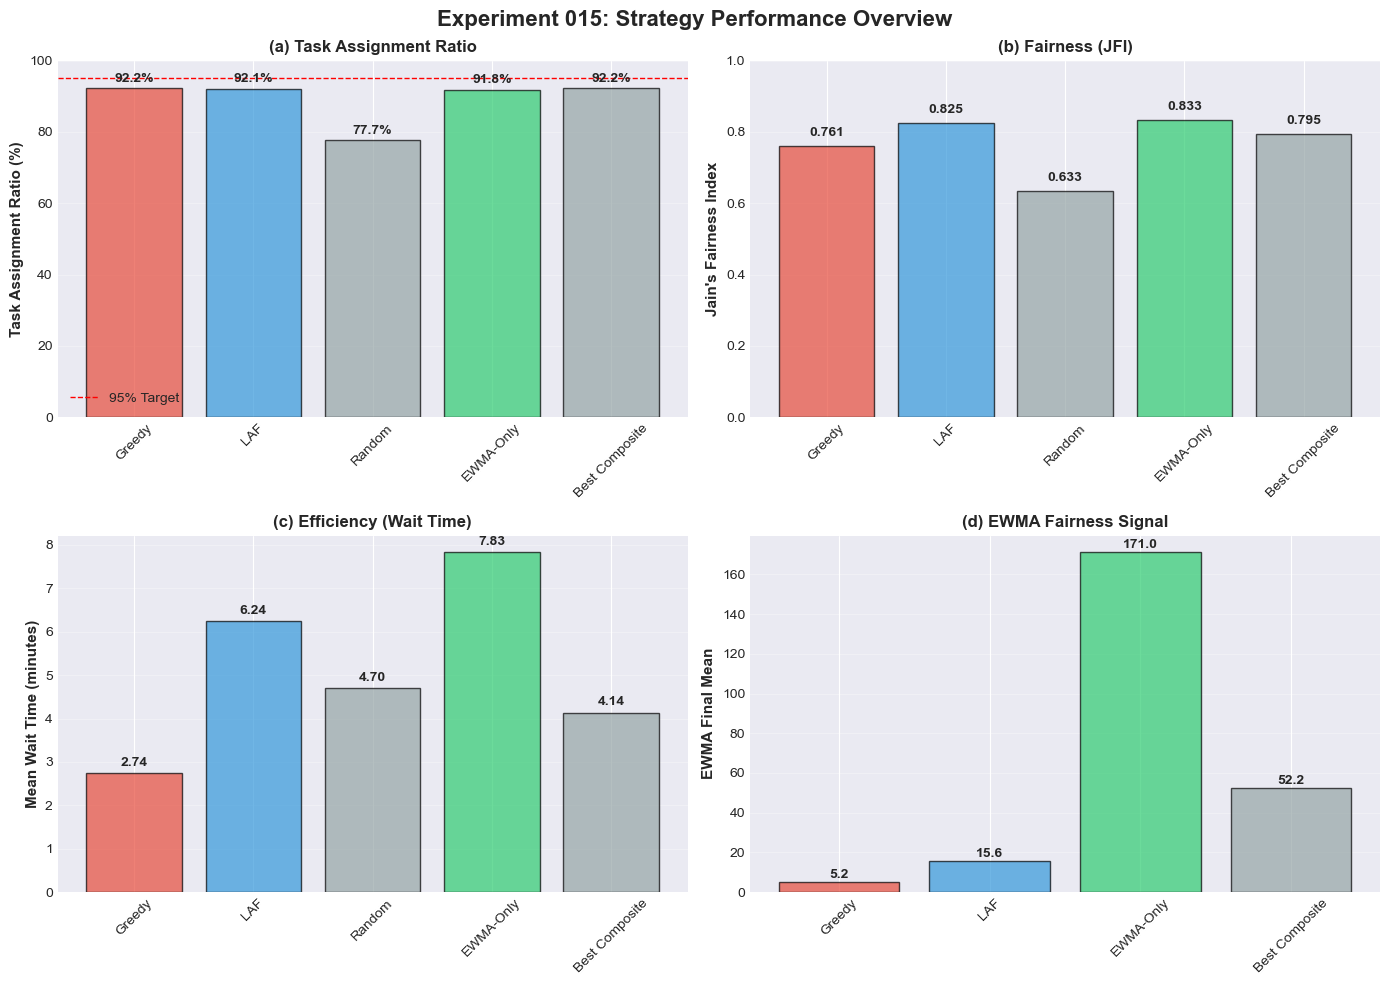

✅ Plot 1a: 4-Panel Overview created


In [ ]:
# Calculate TAR (Task Assignment Ratio)
df['tar'] = df['completed_tasks'] / 20000 * 100  # 20K tasks total

# Get baseline and best composite for comparison
# Note: Random is included automatically if present in data
baselines = df[df['category'].isin(['Greedy', 'LAF', 'EWMA-Only', 'Random'])].copy()
composites = df[df['category'] == 'Composite'].copy()

# Find best composite by JFI
if len(composites) > 0:
    best_composite = composites.loc[composites['jains_fairness_index'].idxmax()].copy()
    best_composite['category'] = 'Best Composite'
    comparison_df = pd.concat([baselines, pd.DataFrame([best_composite])], ignore_index=True)
else:
    comparison_df = baselines.copy()

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Experiment 015: Strategy Performance Overview', fontsize=16, fontweight='bold')

# Plot 1: TAR by strategy
ax1 = axes[0, 0]
categories = comparison_df['category'].tolist()
colors = [STRATEGY_COLORS.get(cat, '#95a5a6') for cat in categories]
ax1.bar(comparison_df['category'], comparison_df['tar'], color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Task Assignment Ratio (%)', fontsize=11, fontweight='bold')
ax1.set_title('(a) Task Assignment Ratio', fontsize=12, fontweight='bold')
ax1.axhline(y=95, color='red', linestyle='--', linewidth=1, label='95% Target')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 100])
for i, v in enumerate(comparison_df['tar']):
    ax1.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

# Plot 2: JFI by strategy
ax2 = axes[0, 1]
ax2.bar(comparison_df['category'], comparison_df['jains_fairness_index'], color=colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel("Jain's Fairness Index", fontsize=11, fontweight='bold')
ax2.set_title('(b) Fairness (JFI)', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0, 1])
for i, v in enumerate(comparison_df['jains_fairness_index']):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: Mean wait time by strategy
ax3 = axes[1, 0]
ax3.bar(comparison_df['category'], comparison_df['mean_wait_time_minutes'], color=colors, alpha=0.7, edgecolor='black')
ax3.set_ylabel('Mean Wait Time (minutes)', fontsize=11, fontweight='bold')
ax3.set_title('(c) Efficiency (Wait Time)', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_df['mean_wait_time_minutes']):
    ax3.text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

# Plot 4: EWMA final mean by strategy
ax4 = axes[1, 1]
ewma_data = comparison_df.dropna(subset=['ewma_final_mean'])
ewma_categories = ewma_data['category'].tolist()
ewma_colors = [STRATEGY_COLORS.get(cat, '#95a5a6') for cat in ewma_categories]
ax4.bar(ewma_data['category'], ewma_data['ewma_final_mean'], color=ewma_colors, alpha=0.7, edgecolor='black')
ax4.set_ylabel('EWMA Final Mean', fontsize=11, fontweight='bold')
ax4.set_title('(d) EWMA Fairness Signal', fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
for i, v in enumerate(ewma_data['ewma_final_mean']):
    ax4.text(i, v + 0.5, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')

# Rotate x-axis labels
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('figures/plot_01a_overview_4panel.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plot 1a: 4-Panel Overview created")


### Plot 1b: Fairness vs Efficiency Scatter


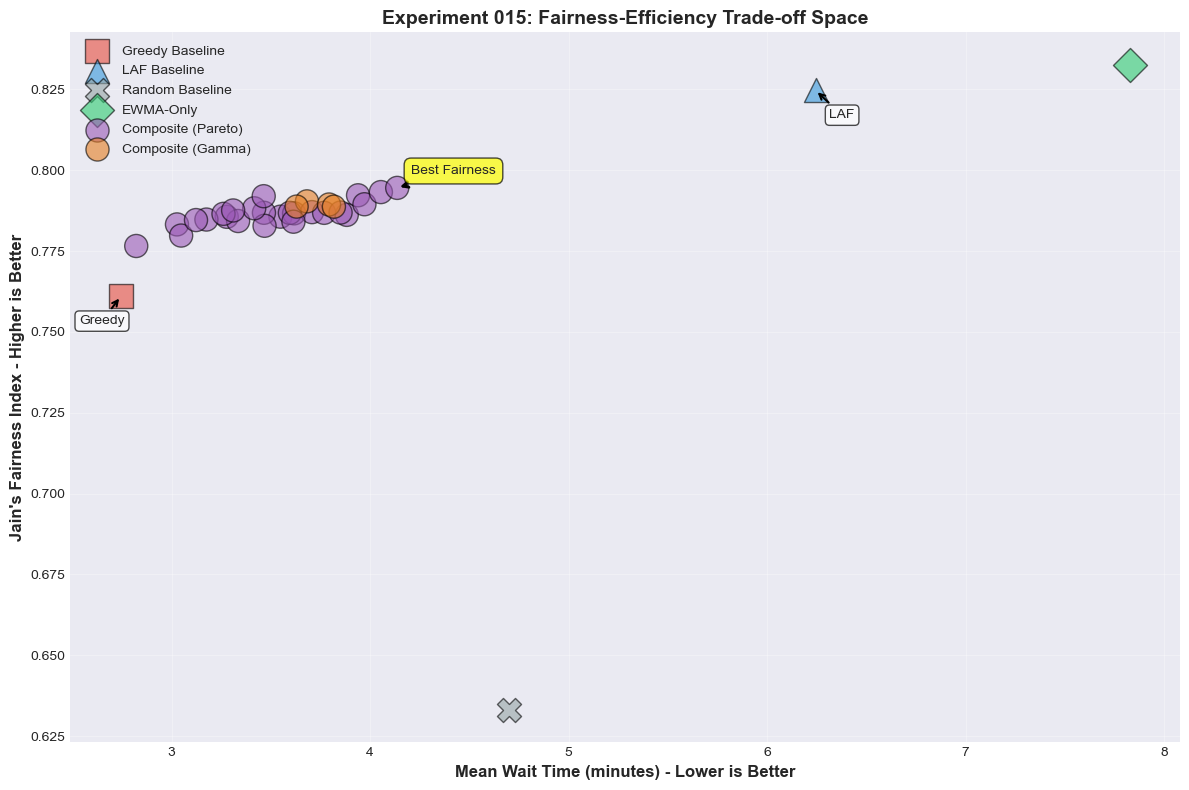

✅ Plot 1b: Fairness vs Efficiency Scatter created


In [ ]:
# Create scatter plot: Fairness vs Efficiency
fig, ax = plt.subplots(figsize=(12, 8))

# Plot different categories with different colors
for category in df['category'].unique():
    if category == 'Other':
        continue
    
    subset = df[df['category'] == category]
    
    # Determine color and marker
    if category == 'Greedy':
        color = STRATEGY_COLORS['Greedy']
        marker = 's'
        size = 300
        label = 'Greedy Baseline'
    elif category == 'LAF':
        color = STRATEGY_COLORS['LAF']
        marker = '^'
        size = 300
        label = 'LAF Baseline'
    elif category == 'Random':
        color = STRATEGY_COLORS['Random']
        marker = 'X'
        size = 300
        label = 'Random Baseline'
    elif category == 'EWMA-Only':
        color = STRATEGY_COLORS['EWMA-Only']
        marker = 'D'
        size = 300
        label = 'EWMA-Only'
    elif category == 'Composite':
        color = STRATEGY_COLORS['Composite']
        marker = 'o'
        size = subset['tar'] * 3  # Size by TAR
        label = 'Composite (Pareto)'
    elif category == 'Composite (Gamma)':
        color = '#e67e22'  # Orange
        marker = 'o'
        size = subset['tar'] * 3
        label = 'Composite (Gamma)'
    else:
        continue
    
    ax.scatter(subset['mean_wait_time_minutes'], 
               subset['jains_fairness_index'],
               c=color, marker=marker, s=size, alpha=0.6, 
               edgecolors='black', linewidth=1, label=label)

# Annotate best composite
if len(composites) > 0:
    best = composites.loc[composites['jains_fairness_index'].idxmax()]
    ax.annotate('Best Fairness', 
                xy=(best['mean_wait_time_minutes'], best['jains_fairness_index']),
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=2))

# Annotate baselines
greedy_row = df[df['category'] == 'Greedy'].iloc[0]
ax.annotate('Greedy', 
            xy=(greedy_row['mean_wait_time_minutes'], greedy_row['jains_fairness_index']),
            xytext=(-30, -20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7),
            arrowprops=dict(arrowstyle='->', lw=1.5))

if 'LAF' in df['category'].values:
    laf_row = df[df['category'] == 'LAF'].iloc[0]
    ax.annotate('LAF', 
                xy=(laf_row['mean_wait_time_minutes'], laf_row['jains_fairness_index']),
                xytext=(10, -20), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7),
                arrowprops=dict(arrowstyle='->', lw=1.5))

ax.set_xlabel('Mean Wait Time (minutes) - Lower is Better', fontsize=12, fontweight='bold')
ax.set_ylabel("Jain's Fairness Index - Higher is Better", fontsize=12, fontweight='bold')
ax.set_title('Experiment 015: Fairness-Efficiency Trade-off Space', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/plot_01b_fairness_efficiency_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plot 1b: Fairness vs Efficiency Scatter created")


### Key Findings - Section 1


In [ ]:
# Print key statistics for executive summary
print("="*80)
print("SECTION 1: KEY FINDINGS")
print("="*80)

greedy = df[df['category'] == 'Greedy'].iloc[0]
print(f"\n🔴 Greedy Baseline:")
print(f"   JFI: {greedy['jains_fairness_index']:.3f}")
print(f"   Wait: {greedy['mean_wait_time_minutes']:.2f} min")
print(f"   TAR: {greedy['tar']:.1f}%")

if 'LAF' in df['category'].values:
    laf = df[df['category'] == 'LAF'].iloc[0]
    print(f"\n🔵 LAF Baseline:")
    print(f"   JFI: {laf['jains_fairness_index']:.3f} (+{((laf['jains_fairness_index']/greedy['jains_fairness_index'])-1)*100:.1f}% vs Greedy)")
    print(f"   Wait: {laf['mean_wait_time_minutes']:.2f} min (+{((laf['mean_wait_time_minutes']/greedy['mean_wait_time_minutes'])-1)*100:.1f}% vs Greedy)")
    print(f"   TAR: {laf['tar']:.1f}%")

if 'EWMA-Only' in df['category'].values:
    ewma = df[df['category'] == 'EWMA-Only'].iloc[0]
    print(f"\n🟢 EWMA-Only:")
    print(f"   JFI: {ewma['jains_fairness_index']:.3f} (+{((ewma['jains_fairness_index']/greedy['jains_fairness_index'])-1)*100:.1f}% vs Greedy)")
    print(f"   Wait: {ewma['mean_wait_time_minutes']:.2f} min (+{((ewma['mean_wait_time_minutes']/greedy['mean_wait_time_minutes'])-1)*100:.1f}% vs Greedy)")
    print(f"   TAR: {ewma['tar']:.1f}%")

if 'Random' in df['category'].values:
    random = df[df['category'] == 'Random'].iloc[0]
    print(f"\n⚪ Random Baseline:")
    print(f"   JFI: {random['jains_fairness_index']:.3f} ({((random['jains_fairness_index']/greedy['jains_fairness_index'])-1)*100:.1f}% vs Greedy)")
    print(f"   Wait: {random['mean_wait_time_minutes']:.2f} min (+{((random['mean_wait_time_minutes']/greedy['mean_wait_time_minutes'])-1)*100:.1f}% vs Greedy)")
    print(f"   TAR: {random['tar']:.1f}% ⚠️ SIGNIFICANTLY LOWER")

if len(composites) > 0:
    best = composites.loc[composites['jains_fairness_index'].idxmax()]
    print(f"\n🟣 Best Composite ({best['exp_name']}):") 
    print(f"   JFI: {best['jains_fairness_index']:.3f} (+{((best['jains_fairness_index']/greedy['jains_fairness_index'])-1)*100:.1f}% vs Greedy)")
    print(f"   Wait: {best['mean_wait_time_minutes']:.2f} min (+{((best['mean_wait_time_minutes']/greedy['mean_wait_time_minutes'])-1)*100:.1f}% vs Greedy)")
    print(f"   TAR: {best['tar']:.1f}%")
    print(f"   λ₁: {best['lambda_1']}, λ₃: {best['lambda_3']}")

print("\n" + "="*80)
print("✅ Section 1 complete!")


SECTION 1: KEY FINDINGS

🔴 Greedy Baseline:
   JFI: 0.761
   Wait: 2.74 min
   TAR: 92.2%

🔵 LAF Baseline:
   JFI: 0.825 (+8.4% vs Greedy)
   Wait: 6.24 min (+127.6% vs Greedy)
   TAR: 92.1%

🟢 EWMA-Only:
   JFI: 0.833 (+9.4% vs Greedy)
   Wait: 7.83 min (+185.2% vs Greedy)
   TAR: 91.8%

⚪ Random Baseline:
   JFI: 0.633 (-16.8% vs Greedy)
   Wait: 4.70 min (+71.3% vs Greedy)
   TAR: 77.7% ⚠️ SIGNIFICANTLY LOWER

🟣 Best Composite (Pareto_L1_4.5_L3_0.5):
   JFI: 0.795 (+4.4% vs Greedy)
   Wait: 4.14 min (+50.7% vs Greedy)
   TAR: 92.2%
   λ₁: 4.5, λ₃: 0.5

✅ Section 1 complete!


---
# Section 2: Baseline Comparison Analysis

Detailed comparison of Greedy, LAF, and EWMA-Only baselines.

**Research Questions**: RQ4.1 (Greedy comparison), RQ4.3 (LAF comparison)


### Plot 2a: Baseline Strategy Comparison


⚠️ Skipping 'Utilization' - no data available in this experiment


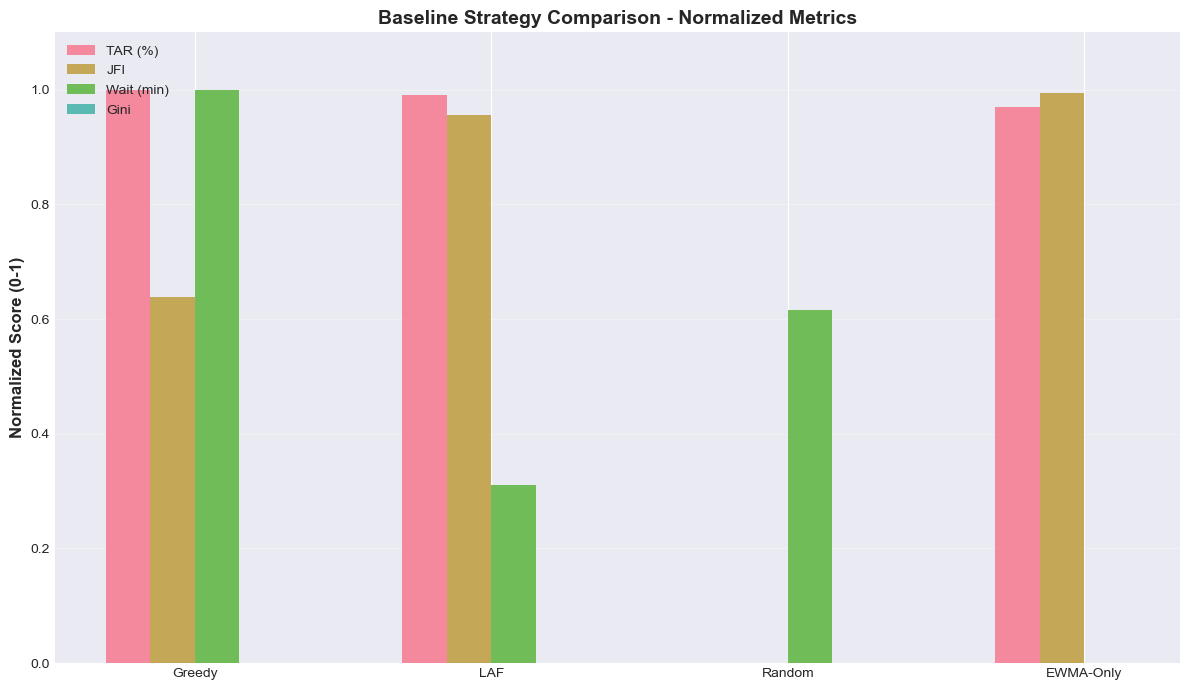

✅ Plot 2a: Baseline Comparison created


In [ ]:
# Get baseline strategies (including Random if present)
baseline_categories = ['Greedy', 'LAF', 'EWMA-Only', 'Random']
baseline_df = df[df['category'].isin(baseline_categories)].copy()

if len(baseline_df) == 0:
    print("⚠️ No baseline strategies found")
else:
    # Prepare data for grouped bar chart
    metrics = {
        'TAR (%)': 'tar',
        'JFI': 'jains_fairness_index',
        'Wait (min)': 'mean_wait_time_minutes',
        'Utilization': 'mean_worker_utilization',
        'Gini': 'gini_coefficient'
    }
    
    # Normalize metrics to [0, 1] for visibility
    normalized_data = {}
    for metric_name, col_name in metrics.items():
        values = baseline_df[col_name].values
        
        # Skip metrics with all NaN or all zero values
        if pd.isna(values).all() or (values == 0).all():
            print(f"⚠️ Skipping '{metric_name}' - no data available in this experiment")
            continue
            
        if metric_name in ['Wait (min)', 'Gini']:  # Lower is better
            normalized = 1 - (values - values.min()) / (values.max() - values.min() + 0.001)
        else:  # Higher is better
            normalized = (values - values.min()) / (values.max() - values.min() + 0.001)
        normalized_data[metric_name] = normalized
    
    # Create grouped bar chart
    fig, ax = plt.subplots(figsize=(12, 7))
    
    x = np.arange(len(baseline_df))
    width = 0.15
    multiplier = 0
    
    for metric_name, norm_values in normalized_data.items():
        offset = width * multiplier
        bars = ax.bar(x + offset, norm_values, width, label=metric_name, alpha=0.8)
        multiplier += 1
    
    ax.set_ylabel('Normalized Score (0-1)', fontsize=12, fontweight='bold')
    ax.set_title('Baseline Strategy Comparison - Normalized Metrics', fontsize=14, fontweight='bold')
    # Center x-ticks based on number of metrics shown
    num_metrics = len(normalized_data)
    ax.set_xticks(x + width * (num_metrics - 1) / 2)
    ax.set_xticklabels(baseline_df['category'])
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.1])
    
    plt.tight_layout()
    plt.savefig('figures/plot_02a_baseline_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Plot 2a: Baseline Comparison created")


---
# Section 3: EWMA-JFI Correlation Analysis ⭐

Validate EWMA as an alternative fairness metric by analyzing its correlation with JFI.

**Research Question**: RQ2.1 - How does EWMA fairness correlate with Jain's Fairness Index?


### Plot 3a: EWMA vs JFI Correlation


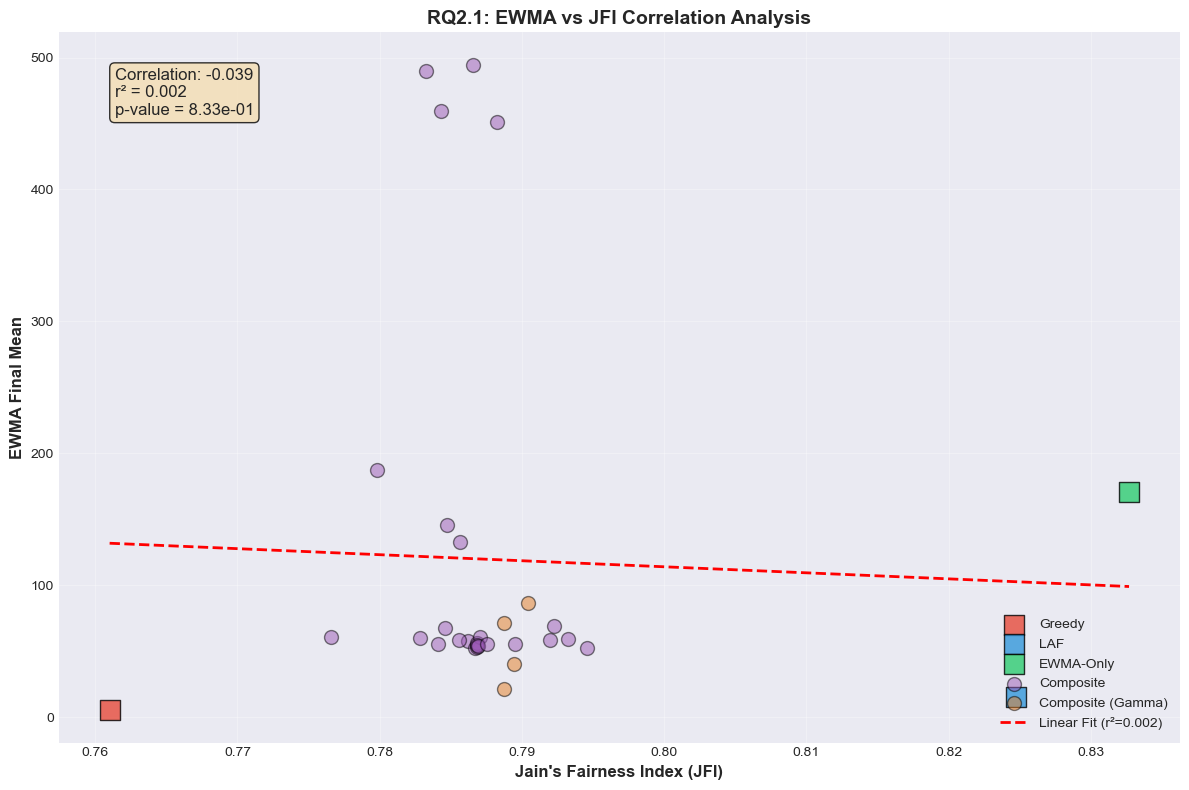

✅ Plot 3a: EWMA-JFI Correlation created
   Correlation coefficient: -0.039
   r² = 0.002
   p-value = 8.33e-01


In [ ]:
# Filter data with EWMA values
ewma_df = df.dropna(subset=['ewma_final_mean', 'jains_fairness_index']).copy()

if len(ewma_df) == 0:
    print("⚠️ No EWMA data available")
else:
    # Calculate correlation
    correlation = ewma_df['ewma_final_mean'].corr(ewma_df['jains_fairness_index'])
    
    # Create scatter plot with regression line
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot by category
    for category in ewma_df['category'].unique():
        if category == 'Other':
            continue
        subset = ewma_df[ewma_df['category'] == category]
        color = STRATEGY_COLORS.get(category, '#95a5a6')
        
        if category == 'Composite':
            marker = 'o'
            alpha = 0.5
            size = 100
        elif category == 'Composite (Gamma)':
            marker = 'o'
            alpha = 0.5
            size = 100
            color = '#e67e22'
        else:
            marker = 's'
            alpha = 0.8
            size = 200
        
        ax.scatter(subset['jains_fairness_index'], subset['ewma_final_mean'],
                  c=color, marker=marker, s=size, alpha=alpha,
                  edgecolors='black', linewidth=1, label=category)
    
    # Add regression line
    from scipy.stats import linregress
    slope, intercept, r_value, p_value, std_err = linregress(
        ewma_df['jains_fairness_index'], 
        ewma_df['ewma_final_mean']
    )
    
    x_line = np.linspace(ewma_df['jains_fairness_index'].min(), 
                         ewma_df['jains_fairness_index'].max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, 'r--', linewidth=2, label=f'Linear Fit (r²={r_value**2:.3f})')
    
    # Add correlation text box
    textstr = f'Correlation: {correlation:.3f}\nr² = {r_value**2:.3f}\np-value = {p_value:.2e}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=props)
    
    ax.set_xlabel("Jain's Fairness Index (JFI)", fontsize=12, fontweight='bold')
    ax.set_ylabel('EWMA Final Mean', fontsize=12, fontweight='bold')
    ax.set_title('RQ2.1: EWMA vs JFI Correlation Analysis', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('figures/plot_03a_ewma_jfi_correlation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Plot 3a: EWMA-JFI Correlation created")
    print(f"   Correlation coefficient: {correlation:.3f}")
    print(f"   r² = {r_value**2:.3f}")
    print(f"   p-value = {p_value:.2e}")


---
# Section 4: Temporal EWMA Evolution ⭐⭐ STAR SECTION

Analyze how EWMA fairness evolves over time during simulation runs.

**Research Questions**: 
- RQ2.3 - Does EWMA better capture temporal fairness patterns?
- RQ2.4 - How quickly does EWMA converge to stable levels?


In [ ]:
# Check temporal data availability
print(f"📊 Temporal EWMA histories available: {len(temporal_data)}")
if len(temporal_data) > 0:
    print(f"   Sample experiments with temporal data:")
    for i, name in enumerate(list(temporal_data.keys())[:5]):
        snapshots = len(temporal_data[name])
        print(f"      {i+1}. {name}: {snapshots} snapshots")
    print(f"\\n✅ Temporal data ready for analysis!")
else:
    print("⚠️ No temporal data found. Temporal analysis will be limited.")


📊 Temporal EWMA histories available: 32
   Sample experiments with temporal data:
      1. Gamma_Balanced_G_0.3: 368 snapshots
      2. Pareto_L1_2.5_L3_1.0: 369 snapshots
      3. Greedy_Baseline: 368 snapshots
      4. LAF_Baseline: 368 snapshots
      5. Pareto_L1_4.0_L3_2.0: 369 snapshots
\n✅ Temporal data ready for analysis!


### Plot 4a: EWMA Evolution - Baseline Comparison


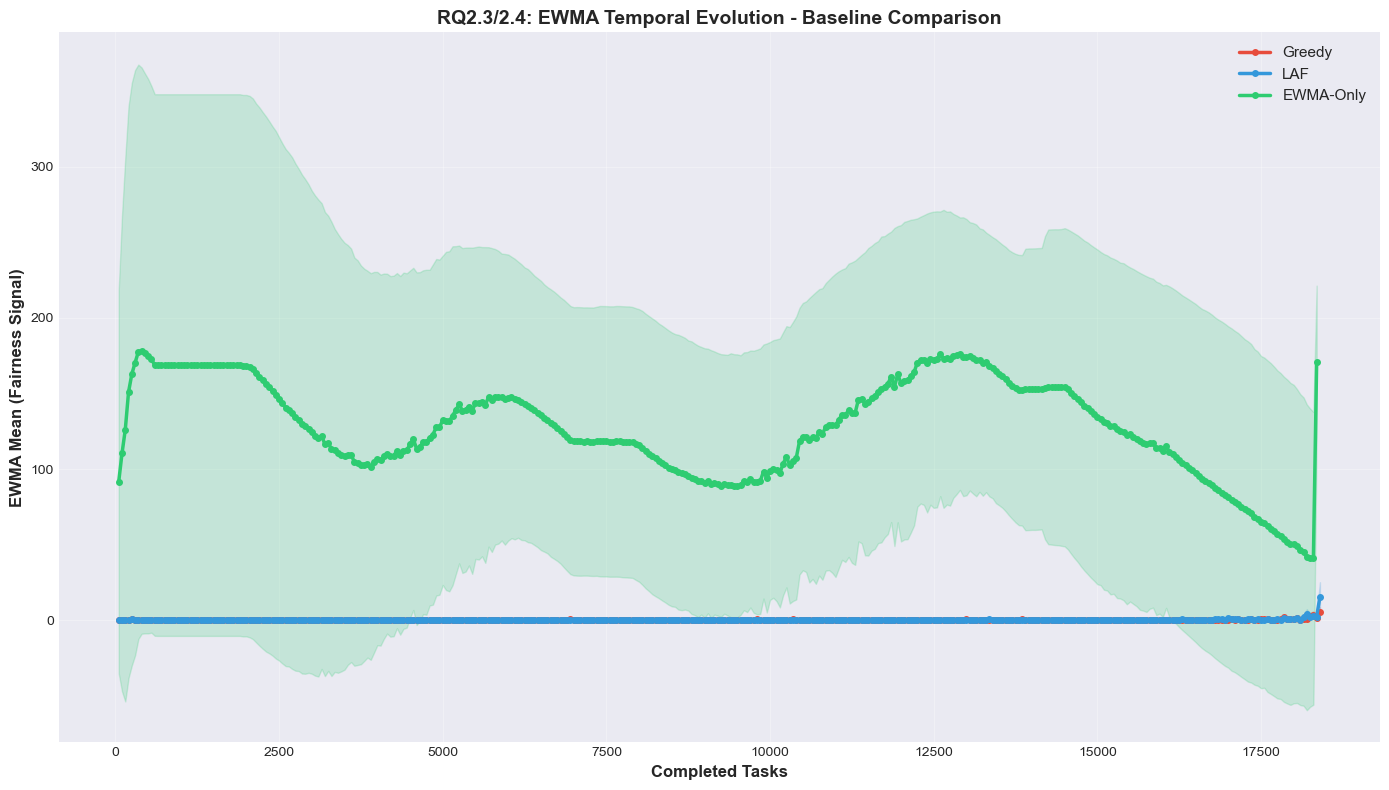

✅ Plot 4a: EWMA Evolution - Baselines created


In [ ]:
# Plot EWMA evolution for baselines
if len(temporal_data) == 0:
    print("⚠️ No temporal data available for this plot")
else:
    fig, ax = plt.subplots(figsize=(14, 8))
    
    baseline_names = ['Greedy_Baseline', 'LAF_Baseline', 'EWMA_Only_G_0.5']
    baseline_labels = ['Greedy', 'LAF', 'EWMA-Only']
    baseline_colors = ['#e74c3c', '#3498db', '#2ecc71']
    
    for name, label, color in zip(baseline_names, baseline_labels, baseline_colors):
        if name in temporal_data:
            history = temporal_data[name]  # This is a DataFrame
            tasks = history['completed_tasks'].values
            ewma_means = history['ewma_mean'].values
            ewma_stds = history['ewma_std'].values
            
            # Plot mean line
            ax.plot(tasks, ewma_means, color=color, linewidth=2.5, label=label, marker='o', markersize=4)
            
            # Add shaded region for ±1 std
            ewma_upper = np.array(ewma_means) + np.array(ewma_stds)
            ewma_lower = np.array(ewma_means) - np.array(ewma_stds)
            ax.fill_between(tasks, ewma_lower, ewma_upper, color=color, alpha=0.2)
    
    ax.set_xlabel('Completed Tasks', fontsize=12, fontweight='bold')
    ax.set_ylabel('EWMA Mean (Fairness Signal)', fontsize=12, fontweight='bold')
    ax.set_title('RQ2.3/2.4: EWMA Temporal Evolution - Baseline Comparison', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('figures/plot_04a_ewma_evolution_baselines.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Plot 4a: EWMA Evolution - Baselines created")


### Plot 4b: EWMA Evolution - Best vs Worst Fairness


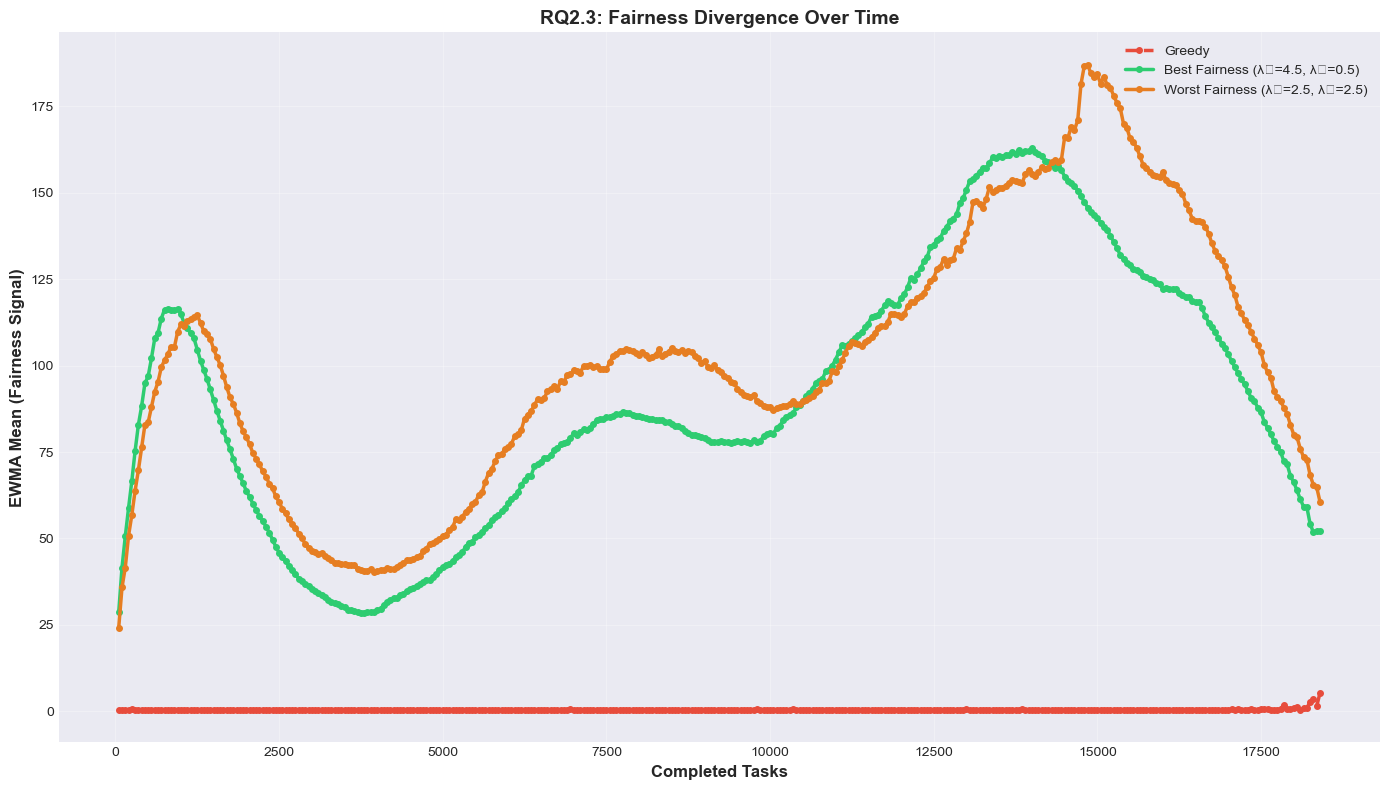

✅ Plot 4b: EWMA Evolution - Best vs Worst created


In [ ]:
# Plot best vs worst composite configurations
if len(composites) == 0 or len(temporal_data) == 0:
    print("⚠️ Insufficient data for this plot")
else:
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Find best and worst by JFI
    best_exp = composites.loc[composites['jains_fairness_index'].idxmax()]
    worst_exp = composites.loc[composites['jains_fairness_index'].idxmin()]
    
    # Plot configurations
    configs = [
        ('Greedy_Baseline', 'Greedy', '#e74c3c', '--'),
        (best_exp['exp_name'], f"Best Fairness (λ₁={best_exp['lambda_1']}, λ₃={best_exp['lambda_3']})", '#2ecc71', '-'),
        (worst_exp['exp_name'], f"Worst Fairness (λ₁={worst_exp['lambda_1']}, λ₃={worst_exp['lambda_3']})", '#e67e22', '-')
    ]
    
    for name, label, color, linestyle in configs:
        if name in temporal_data:
            history = temporal_data[name]  # This is a DataFrame
            tasks = history['completed_tasks'].values
            ewma_means = history['ewma_mean'].values
            
            ax.plot(tasks, ewma_means, color=color, linewidth=2.5, 
                   label=label, linestyle=linestyle, marker='o', markersize=4)
    
    ax.set_xlabel('Completed Tasks', fontsize=12, fontweight='bold')
    ax.set_ylabel('EWMA Mean (Fairness Signal)', fontsize=12, fontweight='bold')
    ax.set_title('RQ2.3: Fairness Divergence Over Time', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('figures/plot_04b_ewma_evolution_best_worst.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Plot 4b: EWMA Evolution - Best vs Worst created")


### Plot 4c: EWMA Convergence Speed Analysis


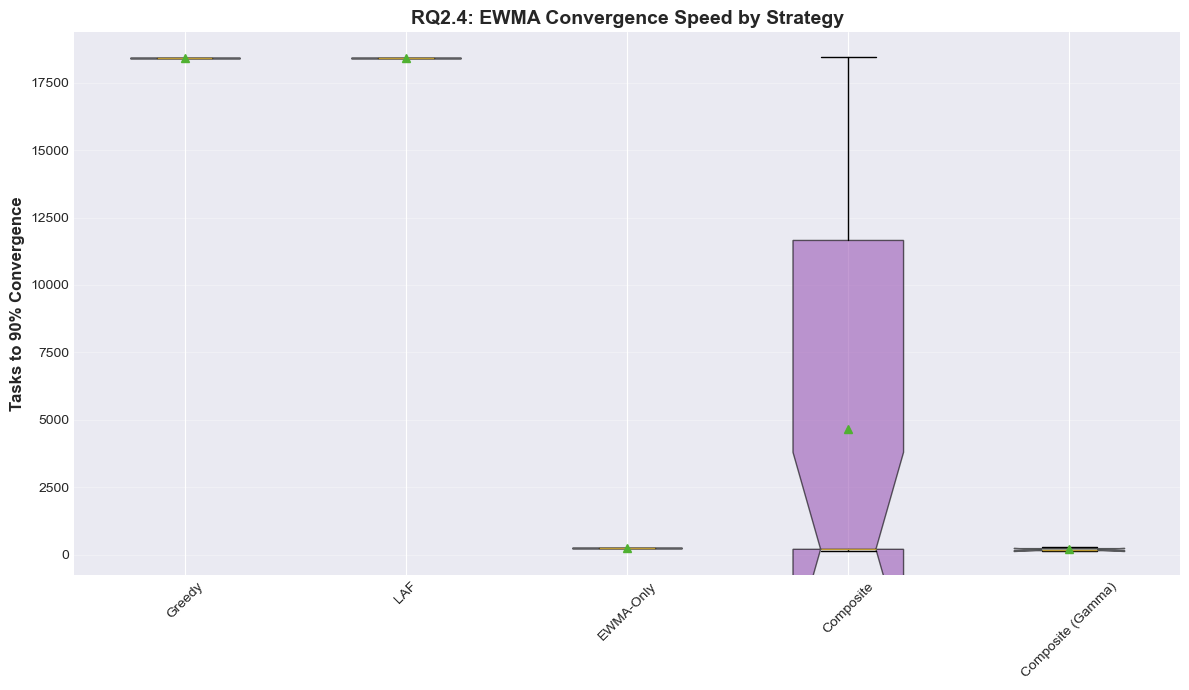

✅ Plot 4c: EWMA Convergence Speed created

Convergence Summary (tasks to 90% of final value):
   Greedy: 18400 ± nan tasks
   LAF: 18400 ± nan tasks
   EWMA-Only: 250 ± nan tasks
   Composite: 4646 ± 7450 tasks
   Composite (Gamma): 200 ± 71 tasks


In [ ]:
# Calculate convergence time (time to reach 90% of final EWMA value)
def calculate_convergence_time(temporal_history, threshold=0.9):
    """Calculate tasks needed to reach threshold% of final EWMA value."""
    # Check if temporal_history is empty or too small
    if temporal_history.empty or len(temporal_history) < 2:
        return None
    
    final_ewma = temporal_history.iloc[-1]['ewma_mean']
    target = threshold * final_ewma
    
    # Iterate through rows to find convergence point
    for idx, row in temporal_history.iterrows():
        if row['ewma_mean'] >= target:
            return row['completed_tasks']
    return temporal_history.iloc[-1]['completed_tasks']

# Calculate for all experiments with temporal data
convergence_data = []
for exp_name, history in temporal_data.items():
    conv_time = calculate_convergence_time(history)
    if conv_time and exp_name in full_summaries:
        summary = full_summaries[exp_name]
        
        # Get category
        matching_row = df[df['exp_name'] == exp_name]
        if len(matching_row) > 0:
            category = matching_row.iloc[0]['category']
            convergence_data.append({
                'exp_name': exp_name,
                'category': category,
                'convergence_tasks': conv_time,
                'final_jfi': summary.get('jains_fairness_index', None)
            })

if len(convergence_data) > 0:
    conv_df = pd.DataFrame(convergence_data)
    
    # Plot convergence time by category
    fig, ax = plt.subplots(figsize=(12, 7))
    
    categories = conv_df['category'].unique()
    category_data = []
    category_labels = []
    
    for cat in ['Greedy', 'LAF', 'EWMA-Only', 'Composite', 'Composite (Gamma)']:
        if cat in categories:
            cat_data = conv_df[conv_df['category'] == cat]['convergence_tasks']
            if len(cat_data) > 0:
                category_data.append(cat_data)
                category_labels.append(cat)
    
    bp = ax.boxplot(category_data, labels=category_labels, patch_artist=True,
                    notch=True, showmeans=True)
    
    # Color boxes
    for patch, label in zip(bp['boxes'], category_labels):
        color = STRATEGY_COLORS.get(label, '#95a5a6')
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.set_ylabel('Tasks to 90% Convergence', fontsize=12, fontweight='bold')
    ax.set_title('RQ2.4: EWMA Convergence Speed by Strategy', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('figures/plot_04c_ewma_convergence_speed.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Plot 4c: EWMA Convergence Speed created")
    print(f"\nConvergence Summary (tasks to 90% of final value):")
    for cat in category_labels:
        cat_conv = conv_df[conv_df['category'] == cat]['convergence_tasks']
        print(f"   {cat}: {cat_conv.mean():.0f} ± {cat_conv.std():.0f} tasks")
else:
    print("⚠️ Insufficient convergence data")


---
# Section 5: Pareto Frontier Analysis

Map the fairness-efficiency trade-off space using λ₁ × λ₃ parameter sweep.

**Research Questions**: RQ1.3 (Pareto frontier), RQ1.4 (optimal configurations)


### Plot 5a: JFI Heatmap (λ₁ × λ₃)


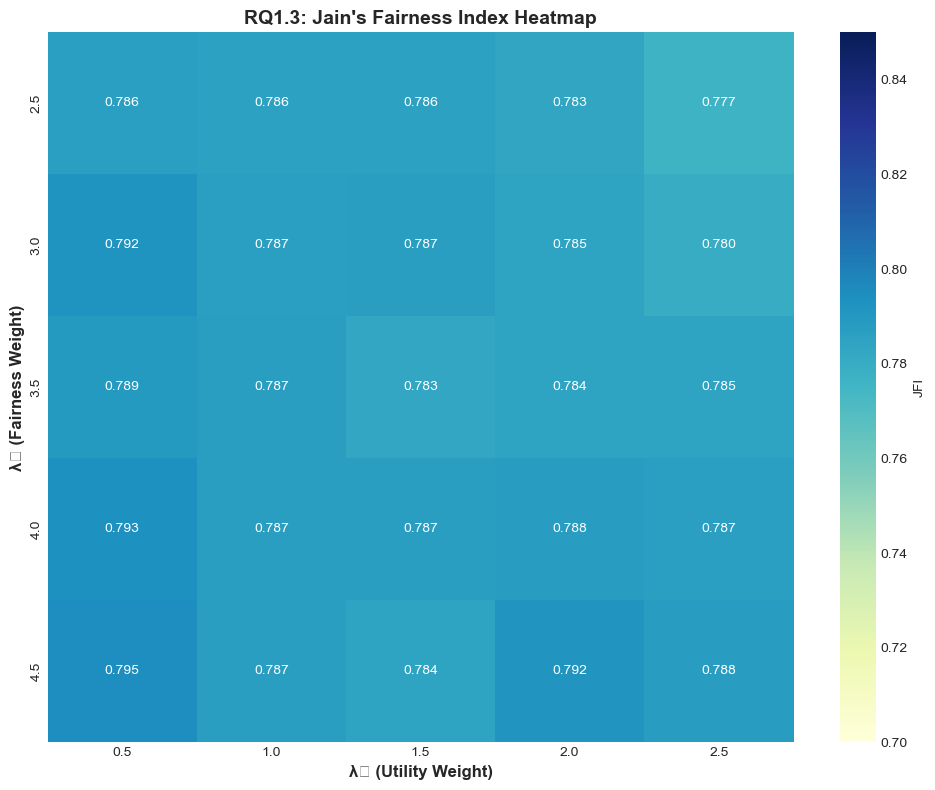

✅ Plot 5a: JFI Heatmap created

📊 Best JFI Configuration:
   λ₁=4.5, λ₃=0.5
   JFI: 0.795
   Wait: 4.14 min


In [ ]:
# Create heatmap for JFI across lambda parameters
pareto_df = df[df['category'] == 'Composite'].copy()

if len(pareto_df) == 0:
    print("⚠️ No Pareto sweep data available")
else:
    # Create pivot table for heatmap
    pivot_jfi = pareto_df.pivot(index='lambda_1', columns='lambda_3', values='jains_fairness_index')
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(pivot_jfi, annot=True, fmt='.3f', cmap='YlGnBu', 
                cbar_kws={'label': 'JFI'}, ax=ax, vmin=0.7, vmax=0.85)
    
    ax.set_xlabel('λ₃ (Utility Weight)', fontsize=12, fontweight='bold')
    ax.set_ylabel('λ₁ (Fairness Weight)', fontsize=12, fontweight='bold')
    ax.set_title('RQ1.3: Jain\'s Fairness Index Heatmap', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('figures/plot_05a_jfi_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Plot 5a: JFI Heatmap created")
    
    # Find best configuration
    best_idx = pareto_df['jains_fairness_index'].idxmax()
    best_config = pareto_df.loc[best_idx]
    print(f"\n📊 Best JFI Configuration:")
    print(f"   λ₁={best_config['lambda_1']}, λ₃={best_config['lambda_3']}")
    print(f"   JFI: {best_config['jains_fairness_index']:.3f}")
    print(f"   Wait: {best_config['mean_wait_time_minutes']:.2f} min")


### Plot 5b: Wait Time Heatmap (λ₁ × λ₃)


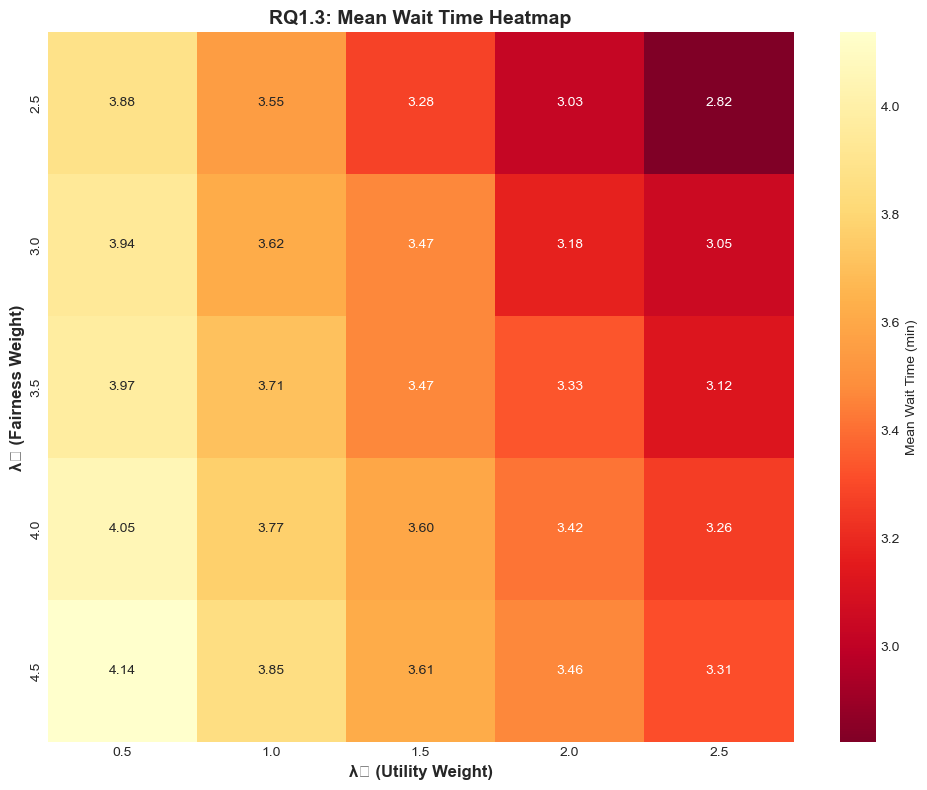

✅ Plot 5b: Wait Time Heatmap created

📊 Best Efficiency Configuration:
   λ₁=2.5, λ₃=2.5
   Wait: 2.82 min
   JFI: 0.777


In [ ]:
# Create heatmap for wait time across lambda parameters
if len(pareto_df) > 0:
    # Create pivot table for heatmap
    pivot_wait = pareto_df.pivot(index='lambda_1', columns='lambda_3', values='mean_wait_time_minutes')
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(pivot_wait, annot=True, fmt='.2f', cmap='YlOrRd_r', 
                cbar_kws={'label': 'Mean Wait Time (min)'}, ax=ax)
    
    ax.set_xlabel('λ₃ (Utility Weight)', fontsize=12, fontweight='bold')
    ax.set_ylabel('λ₁ (Fairness Weight)', fontsize=12, fontweight='bold')
    ax.set_title('RQ1.3: Mean Wait Time Heatmap', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('figures/plot_05b_wait_time_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Plot 5b: Wait Time Heatmap created")
    
    # Find best efficiency
    best_eff_idx = pareto_df['mean_wait_time_minutes'].idxmin()
    best_eff_config = pareto_df.loc[best_eff_idx]
    print(f"\n📊 Best Efficiency Configuration:")
    print(f"   λ₁={best_eff_config['lambda_1']}, λ₃={best_eff_config['lambda_3']}")
    print(f"   Wait: {best_eff_config['mean_wait_time_minutes']:.2f} min")
    print(f"   JFI: {best_eff_config['jains_fairness_index']:.3f}")


---
# Section 6: Final Summary & Research Question Answers

Synthesize findings and provide deployment recommendations.


### Summary Table: Strategy Performance Comparison


In [ ]:
# Create comprehensive summary table
summary_rows = []

# Greedy baseline
greedy = df[df['category'] == 'Greedy'].iloc[0]
summary_rows.append({
    'Strategy': 'Greedy',
    'TAR (%)': f"{greedy['tar']:.1f}",
    'JFI': f"{greedy['jains_fairness_index']:.3f}",
    'Wait (min)': f"{greedy['mean_wait_time_minutes']:.2f}",
    'EWMA': f"{greedy.get('ewma_final_mean', 'N/A')}",
    'Use Case': 'Efficiency priority, low fairness'
})

# LAF baseline
if 'LAF' in df['category'].values:
    laf = df[df['category'] == 'LAF'].iloc[0]
    summary_rows.append({
        'Strategy': 'LAF',
        'TAR (%)': f"{laf['tar']:.1f}",
        'JFI': f"{laf['jains_fairness_index']:.3f}",
        'Wait (min)': f"{laf['mean_wait_time_minutes']:.2f}",
        'EWMA': f"{laf.get('ewma_final_mean', 'N/A')}",
        'Use Case': 'High fairness, poor efficiency'
    })

# EWMA-Only
if 'EWMA-Only' in df['category'].values:
    ewma = df[df['category'] == 'EWMA-Only'].iloc[0]
    summary_rows.append({
        'Strategy': 'EWMA-Only (γ=0.5)',
        'TAR (%)': f"{ewma['tar']:.1f}",
        'JFI': f"{ewma['jains_fairness_index']:.3f}",
        'Wait (min)': f"{ewma['mean_wait_time_minutes']:.2f}",
        'EWMA': f"{ewma.get('ewma_final_mean', 'N/A')}",
        'Use Case': 'Temporal fairness focus'
    })

# Random baseline
if 'Random' in df['category'].values:
    random = df[df['category'] == 'Random'].iloc[0]
    summary_rows.append({
        'Strategy': 'Random (k=15)',
        'TAR (%)': f"{random['tar']:.1f}",
        'JFI': f"{random['jains_fairness_index']:.3f}",
        'Wait (min)': f"{random['mean_wait_time_minutes']:.2f}",
        'EWMA': 'N/A',
        'Use Case': 'Null hypothesis baseline (RQ4.2)'
    })

# Best composite
if len(composites) > 0:
    best = composites.loc[composites['jains_fairness_index'].idxmax()]
    summary_rows.append({
        'Strategy': f"Best Composite (λ₁={best['lambda_1']}, λ₃={best['lambda_3']})",
        'TAR (%)': f"{best['tar']:.1f}",
        'JFI': f"{best['jains_fairness_index']:.3f}",
        'Wait (min)': f"{best['mean_wait_time_minutes']:.2f}",
        'EWMA': f"{best.get('ewma_final_mean', 'N/A')}",
        'Use Case': 'Optimal fairness-efficiency balance'
    })

summary_table = pd.DataFrame(summary_rows)

print("="*100)
print("EXPERIMENT 015: FINAL SUMMARY")
print("="*100)
print(summary_table.to_string(index=False))
print("="*100)


EXPERIMENT 015: FINAL SUMMARY
                       Strategy TAR (%)   JFI Wait (min)               EWMA                            Use Case
                         Greedy    92.2 0.761       2.74  5.237303520064292   Efficiency priority, low fairness
                            LAF    92.1 0.825       6.24 15.568493777397189      High fairness, poor efficiency
              EWMA-Only (γ=0.5)    91.8 0.833       7.83 171.02090387404897             Temporal fairness focus
                  Random (k=15)    77.7 0.633       4.70                N/A    Null hypothesis baseline (RQ4.2)
Best Composite (λ₁=4.5, λ₃=0.5)    92.2 0.795       4.14  52.20024615004728 Optimal fairness-efficiency balance
